<a href="https://colab.research.google.com/github/Adjacent-Yan/StellarClassification/blob/main/171_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)

df = pd.read_csv("./star_classification.csv")

drop_cols = [
    "obj_ID", "alpha", "delta", "run_ID", "rerun_ID",
    "cam_col", "field_ID", "spec_obj_ID", "plate",
    "MJD", "fiber_ID"
]

df.drop(columns=drop_cols, inplace=True)

cols = ["u", "g", "r", "i", "z"]

before = len(df)

rows_to_drop = df[(df[cols] == -9999).any(axis=1)]
df = df.drop(index=rows_to_drop.index)

after = len(df)

print("\n" + "-" * 70)
print("Exploratory Data Analysis")
print("-" * 70)

print(f"Outliers dropped: {before - after}")
print("Number of duplicates:", df.duplicated().sum())

print()
print(df.info())

print()
print(df.describe())

print()
print(df["class"].value_counts())


----------------------------------------------------------------------
Exploratory Data Analysis
----------------------------------------------------------------------
Outliers dropped: 1
Number of duplicates: 0

<class 'pandas.core.frame.DataFrame'>
Index: 99999 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   u         99999 non-null  float64
 1   g         99999 non-null  float64
 2   r         99999 non-null  float64
 3   i         99999 non-null  float64
 4   z         99999 non-null  float64
 5   class     99999 non-null  object 
 6   redshift  99999 non-null  float64
dtypes: float64(6), object(1)
memory usage: 6.1+ MB
None

                  u             g             r             i             z  \
count  99999.000000  99999.000000  99999.000000  99999.000000  99999.000000   
mean      22.080679     20.631583     19.645777     19.084865     18.768988   
std        2.251068      2.037384    

In [2]:
!pip install imbalanced-learn

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

from imblearn.under_sampling import RandomUnderSampler

import matplotlib.pyplot as plt

In [4]:
features = ["u", "g", "r", "i", "z", "redshift"]

X = df[features]
y = df["class"]

print(X.head())
print()
print(y.value_counts())

          u         g         r         i         z  redshift
0  23.87882  22.27530  20.39501  19.16573  18.79371  0.634794
1  24.77759  22.83188  22.58444  21.16812  21.61427  0.779136
2  25.26307  22.66389  20.60976  19.34857  18.94827  0.644195
3  22.13682  23.77656  21.61162  20.50454  19.25010  0.932346
4  19.43718  17.58028  16.49747  15.97711  15.54461  0.116123

class
GALAXY    59445
STAR      21593
QSO       18961
Name: count, dtype: int64


In [5]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

for class_name, number in zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
):
    print(class_name, "=", number)

GALAXY = 0
QSO = 1
STAR = 2


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    stratify=y_encoded,
    random_state=42
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_validation))
print("Testing rows:", len(X_test))

Training rows: 69999
Validation rows: 15000
Testing rows: 15000


In [7]:
undersampler = RandomUnderSampler(random_state=42)

X_train_balanced, y_train_balanced = undersampler.fit_resample(
    X_train,
    y_train
)

print("Before undersampling:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nAfter undersampling:")
print(pd.Series(y_train_balanced).value_counts().sort_index())

Before undersampling:
0    41611
1    13273
2    15115
Name: count, dtype: int64

After undersampling:
0    13273
1    13273
2    13273
Name: count, dtype: int64


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_balanced)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")

Scaling complete


In [9]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train_balanced)

print("KNN training complete")

KNN training complete


In [10]:
validation_predictions = knn.predict(X_validation_scaled)

validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions
)

validation_precision = precision_score(
    y_validation,
    validation_predictions,
    average="macro"
)

validation_recall = recall_score(
    y_validation,
    validation_predictions,
    average="macro"
)

validation_f1 = f1_score(
    y_validation,
    validation_predictions,
    average="macro"
)

print("Validation Accuracy:", validation_accuracy)
print("Validation Macro Precision:", validation_precision)
print("Validation Macro Recall:", validation_recall)
print("Validation Macro F1:", validation_f1)

Validation Accuracy: 0.9492
Validation Macro Precision: 0.9343126982399822
Validation Macro Recall: 0.9551438944565249
Validation Macro F1: 0.9439239816540653


In [11]:
print(
    classification_report(
        y_validation,
        validation_predictions,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

      GALAXY       0.98      0.94      0.96      8917
         QSO       0.92      0.94      0.93      2844
        STAR       0.90      0.99      0.94      3239

    accuracy                           0.95     15000
   macro avg       0.93      0.96      0.94     15000
weighted avg       0.95      0.95      0.95     15000



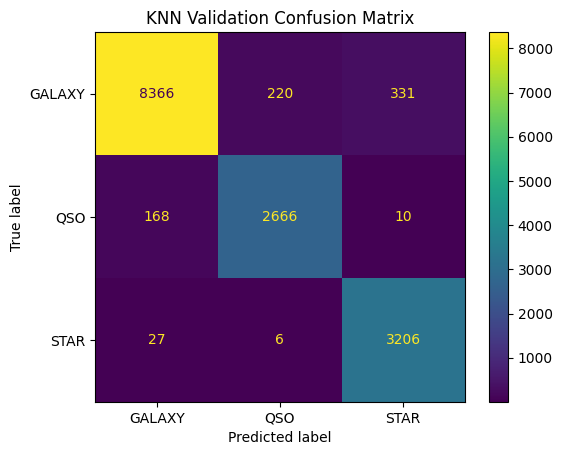

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    validation_predictions,
    display_labels=encoder.classes_
)

plt.title("KNN Validation Confusion Matrix")
plt.show()

In [13]:
results = []

for k in [3, 5, 7, 9, 11]:
    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_scaled, y_train_balanced)

    predictions = model.predict(X_validation_scaled)

    results.append({
        "K": k,
        "Accuracy": accuracy_score(
            y_validation,
            predictions
        ),
        "Macro F1": f1_score(
            y_validation,
            predictions,
            average="macro"
        )
    })

results_df = pd.DataFrame(results)
results_df

,K,Accuracy,Macro F1
0,3,0.949067,0.943636
1,5,0.949200,0.943924
2,7,0.948000,0.942756
3,9,0.946533,0.941288
4,11,0.945200,0.939983


In [14]:
best_k = 5

final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(X_train_scaled, y_train_balanced)

test_predictions = final_knn.predict(X_test_scaled)

print("Best K:", best_k)

print(
    "Test Accuracy:",
    accuracy_score(y_test, test_predictions)
)

print(
    "Test Macro Precision:",
    precision_score(
        y_test,
        test_predictions,
        average="macro"
    )
)

print(
    "Test Macro Recall:",
    recall_score(
        y_test,
        test_predictions,
        average="macro"
    )
)

print(
    "Test Macro F1:",
    f1_score(
        y_test,
        test_predictions,
        average="macro"
    )
)

Best K: 5
Test Accuracy: 0.9486666666666667
Test Macro Precision: 0.932493088369605
Test Macro Recall: 0.9572371404582949
Test Macro F1: 0.9438987490393878
